In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)

In [6]:
p1g =pd.read_csv('../datos/brutos/Planta1_Generacion.csv')
p2g = pd.read_csv('../datos/brutos/Planta2_Generacion.csv')
p1s = pd.read_csv('../datos/brutos/Planta1_Sensores.csv')
p2s = pd.read_csv('../datos/brutos/Planta2_Sensores.csv')

In [22]:
p2g = pd.read_csv('../datos/brutos/Planta2_Generacion.csv')

In [10]:
p1g.info()

<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fecha_hora          68778 non-null  str    
 1   id_planta           68778 non-null  int64  
 2   id_inversor         68778 non-null  str    
 3   potencia_dc_kw      68778 non-null  float64
 4   potencia_ac_kw      68778 non-null  float64
 5   energia_diaria_kwh  68778 non-null  float64
 6   energia_total_kwh   68778 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 3.7 MB


In [12]:
# convertir 'fecha_hora' a datetime con dayfirst=True
p1g['fecha_hora'] = pd.to_datetime(p1g['fecha_hora'].astype(str).str.strip(), dayfirst=True, errors='coerce')

# fijar id_planta = 'p1' para todos los registros
p1g['id_planta'] = 'p1'

# comprobación rápida
p1g.info()
p1g.head()

<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fecha_hora          68778 non-null  datetime64[us]
 1   id_planta           68778 non-null  str           
 2   id_inversor         68778 non-null  str           
 3   potencia_dc_kw      68778 non-null  float64       
 4   potencia_ac_kw      68778 non-null  float64       
 5   energia_diaria_kwh  68778 non-null  float64       
 6   energia_total_kwh   68778 non-null  float64       
dtypes: datetime64[us](1), float64(4), str(2)
memory usage: 3.7 MB


,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
0,2020-05-15,p1,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15,p1,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15,p1,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,2020-05-15,p1,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,2020-05-15,p1,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [24]:
# convertir 'fecha_hora' a datetime con dayfirst=True
p2g['fecha_hora'] = pd.to_datetime(p2g['fecha_hora'], dayfirst=True)

# fijar id_planta = 'p1' para todos los registros
p2g['id_planta'] = 'p2'

# comprobación rápida
p2g.head()

C:\Users\Jordini\AppData\Local\Temp\ipykernel_9736\1468621952.py:2: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  p2g['fecha_hora'] = pd.to_datetime(p2g['fecha_hora'], dayfirst=True)


,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
0,2020-05-15,p2,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06
1,2020-05-15,p2,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09
2,2020-05-15,p2,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09
3,2020-05-15,p2,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06
4,2020-05-15,p2,IQ2d7wF4YD8zU1Q,0.0,0.0,3177.000000,1.994153e+07


In [27]:
p1s['fecha_hora']= pd.to_datetime(p1s['fecha_hora'], dayfirst=True)
p1s['id_planta'] = 'p1'
p1s.info()

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   fecha_hora               3182 non-null   datetime64[us]
 1   id_planta                3182 non-null   str           
 2   id_sensor_meteorologico  3182 non-null   str           
 3   temperatura_ambiente_c   3182 non-null   float64       
 4   temperatura_modulo_c     3182 non-null   float64       
 5   irradiacion_wh_m2        3182 non-null   float64       
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 149.3 KB


C:\Users\Jordini\AppData\Local\Temp\ipykernel_9736\3147360652.py:1: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  p1s['fecha_hora']= pd.to_datetime(p1s['fecha_hora'], dayfirst=True)


In [29]:
p2s['fecha_hora']= pd.to_datetime(p2s['fecha_hora'], dayfirst=True)
p2s['id_planta'] = 'p2'
p2s.head()

C:\Users\Jordini\AppData\Local\Temp\ipykernel_9736\1898988383.py:1: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  p2s['fecha_hora']= pd.to_datetime(p2s['fecha_hora'], dayfirst=True)


,fecha_hora,id_planta,id_sensor_meteorologico,temperatura_ambiente_c,temperatura_modulo_c,irradiacion_wh_m2
0,2020-05-15 00:00:00,p2,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
1,2020-05-15 00:15:00,p2,iq8k7ZNt4Mwm3w0,26.880811,24.421869,0.0
2,2020-05-15 00:30:00,p2,iq8k7ZNt4Mwm3w0,26.682055,24.427290,0.0
3,2020-05-15 00:45:00,p2,iq8k7ZNt4Mwm3w0,26.500589,24.420678,0.0
4,2020-05-15 01:00:00,p2,iq8k7ZNt4Mwm3w0,26.596148,25.088210,0.0


In [32]:
datasets = {
    'p1g': p1g,
    'p2g': p2g,
    'p1s': p1s,
    'p2s': p2s,
}

def summarize_dataset(df, name):
    s = df['fecha_hora']
    if not np.issubdtype(s.dtype, np.datetime64):
        s = pd.to_datetime(s.astype(str).str.strip(), dayfirst=True, errors='coerce')

    s = s.dropna().sort_values().drop_duplicates()
    diffs = s.diff().dropna()
    expected = pd.Timedelta(minutes=15)

    return {
        'dataset': name,
        'rows': len(df),
        'unique_timestamps': len(s),
        'start': s.iloc[0] if len(s) else pd.NaT,
        'end': s.iloc[-1] if len(s) else pd.NaT,
        'constant_interval': diffs.nunique() == 1 if len(diffs) else False,
        'min_step': diffs.min() if len(diffs) else None,
        'max_step': diffs.max() if len(diffs) else None,
        'expected_step_15min': expected,
        'interval_counts': diffs.value_counts().sort_index().to_dict(),
        'parse_failures': df['fecha_hora'].isna().sum() if np.issubdtype(df['fecha_hora'].dtype, np.datetime64) else pd.to_datetime(df['fecha_hora'].astype(str).str.strip(), dayfirst=True, errors='coerce').isna().sum(),
    }

summary = [summarize_dataset(df, name) for name, df in datasets.items()]
summary_df = pd.DataFrame(summary)
summary_df

,dataset,rows,unique_timestamps,start,end,constant_interval,min_step,max_step,expected_step_15min,interval_counts,parse_failures
0,p1g,68778,3158,2020-05-15,2020-06-17 23:45:00,False,0 days 00:15:00,0 days 09:00:00,0 days 00:15:00,"{0 days 00:15:00: 3148, 0 days 00:30:00: 2, 0 ...",0
1,p2g,67698,3259,2020-05-15,2020-06-17 23:45:00,False,0 days 00:15:00,0 days 00:30:00,0 days 00:15:00,"{0 days 00:15:00: 3253, 0 days 00:30:00: 5}",0
2,p1s,3182,3182,2020-05-15,2020-06-17 23:45:00,False,0 days 00:15:00,0 days 07:15:00,0 days 00:15:00,"{0 days 00:15:00: 3173, 0 days 00:30:00: 2, 0 ...",0
3,p2s,3259,3259,2020-05-15,2020-06-17 23:45:00,False,0 days 00:15:00,0 days 00:30:00,0 days 00:15:00,"{0 days 00:15:00: 3253, 0 days 00:30:00: 5}",0


### Resumen (regularización de series temporales)

1. Siempre que trabajemos con proyectos en los que las series temporales tienen relevancia tenemos que hacer un análisis de la regularidad de las series temporales. Esto nos permitirá identificar problemas de calidad de datos y tomar decisiones informadas sobre cómo manejarlos.
2. Hay que analizar estas series temporales acorde al origen de estas series temporales. Por ejemplo en éste caso serian ventanas de 15 minutos.
3. Hay que decidir si regularizar o no los registros del dataset. Para ello, lo decidimos en funcion de 2 parametros: si alguna herramienta nos obliga a regularizarlo (en el caso de hacer modelos de prediccion). En este caso, como no aplica, valoramos pros y contras. En este caso concreto regularizar los datos nos podria afectar a la propia correcta evaluacion de los datos originales, los cuales necesitamos para sacar insights. Por ejemplo podriamos encontrar patrones dentro de esos intervalos vacios de datos que nos ayuden a identificar fallos de medicion, etc. Debido a eso, no los regularizaremos.

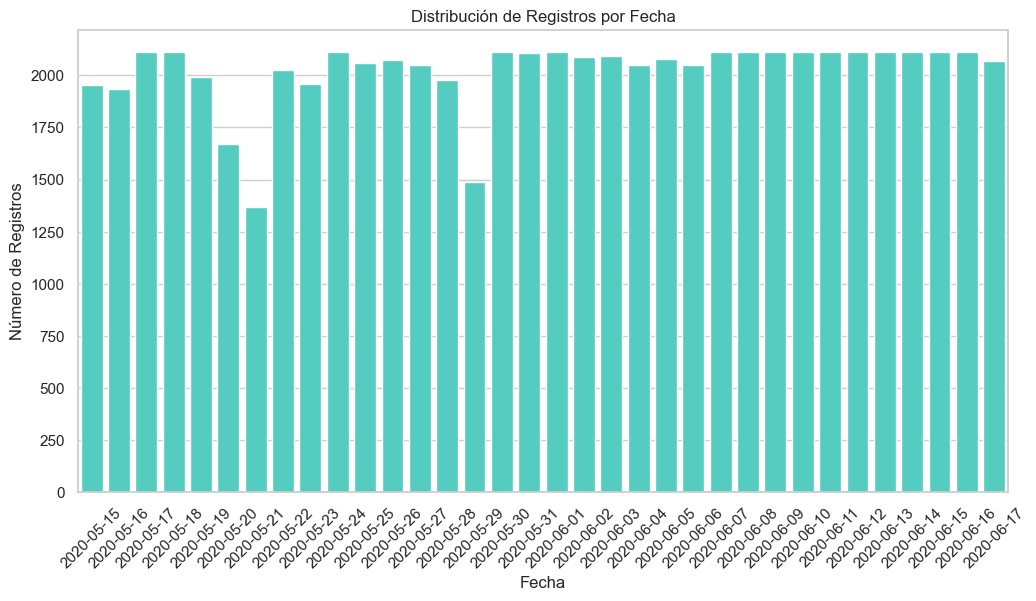

In [41]:
#Grafico de barras de numero de registros totales diario (groupby por fecha_hora) en p1g con etiquetas de tiempo en eje x en todas las fechas disponibles en el dataset, con rotacion de 45 grados para las etiquetas del eje x y titulo "Distribución de Registros por Fecha"
plt.figure(figsize=(12, 6))
p1g['fecha'] = p1g['fecha_hora'].dt.date
daily_counts = p1g.groupby('fecha').size()
sns.barplot(x=daily_counts.index, y=daily_counts.values, color='turquoise')
plt.xticks(rotation=45)
plt.title("Distribución de Registros por Fecha")
plt.xlabel("Fecha")
plt.ylabel("Número de Registros")
plt.show()


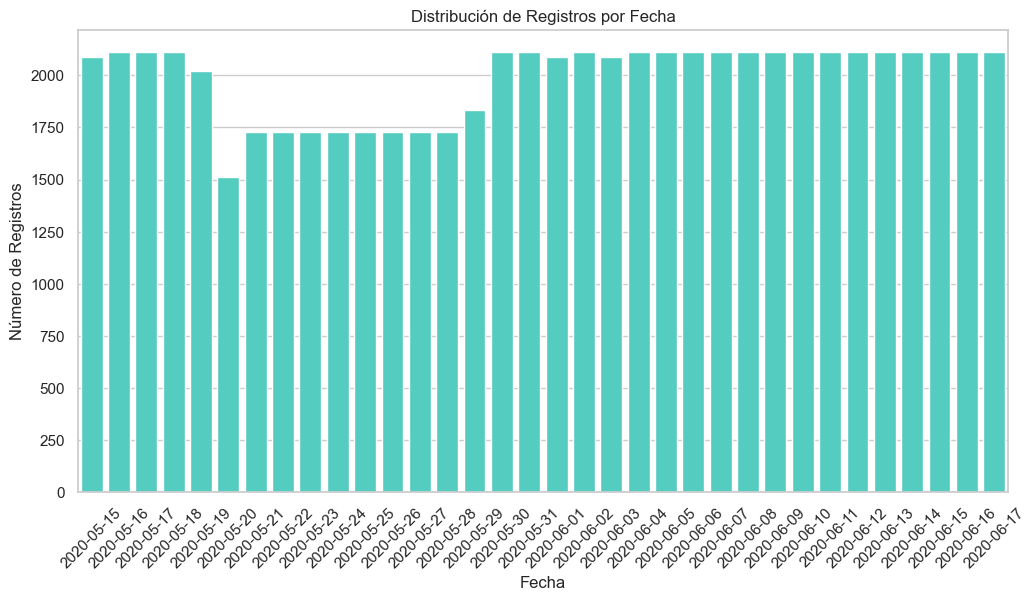

In [42]:
#Grafico de barras de registros totales diario (groupby por fecha_hora) en p2g con etiquetas de tiempo en eje x en todas las fechas disponibles en el dataset, con rotacion de 45 grados para las etiquetas del eje x y titulo "Distribución de Registros por Fecha"
plt.figure(figsize=(12, 6))
p2g['fecha'] = p2g['fecha_hora'].dt.date
daily_counts = p2g.groupby('fecha').size()
sns.barplot(x=daily_counts.index, y=daily_counts.values, color='turquoise')
plt.xticks(rotation=45)
plt.title("Distribución de Registros por Fecha")
plt.xlabel("Fecha")
plt.ylabel("Número de Registros")
plt.show()

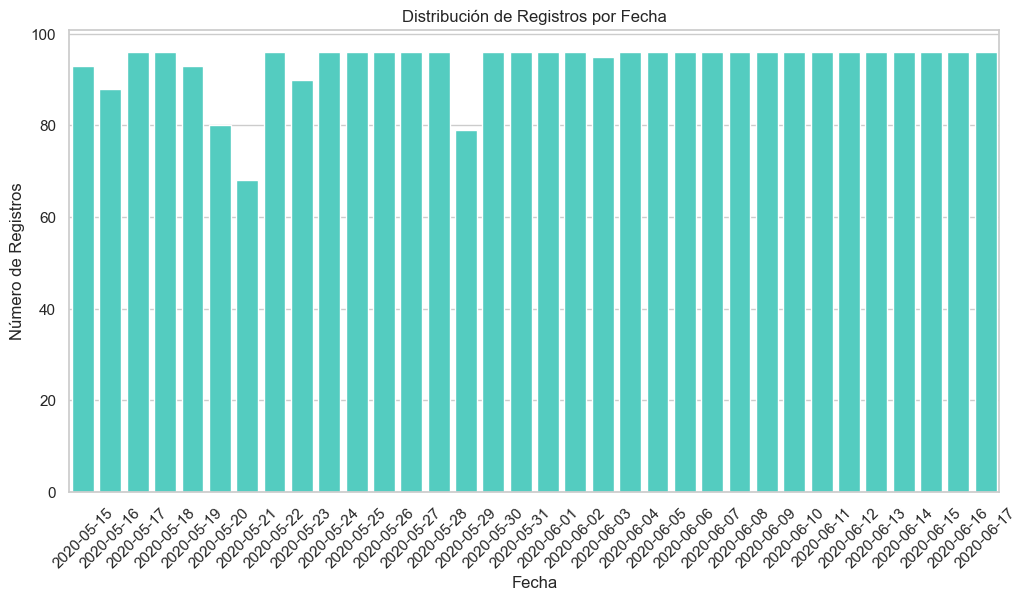

In [40]:
#Grafico de barras de registros totales diario (groupby por fecha_hora) en p1s con etiquetas de tiempo en eje x en todas las fechas disponibles en el dataset, con rotacion de 45 grados para las etiquetas del eje x y titulo "Distribución de Registros por Fecha"
plt.figure(figsize=(12, 6))
p1s['fecha'] = p1s['fecha_hora'].dt.date
daily_counts = p1s.groupby('fecha').size()
sns.barplot(x=daily_counts.index, y=daily_counts.values, color='turquoise')
plt.xticks(rotation=45)
plt.title("Distribución de Registros por Fecha")
plt.xlabel("Fecha")
plt.ylabel("Número de Registros")
plt.show()

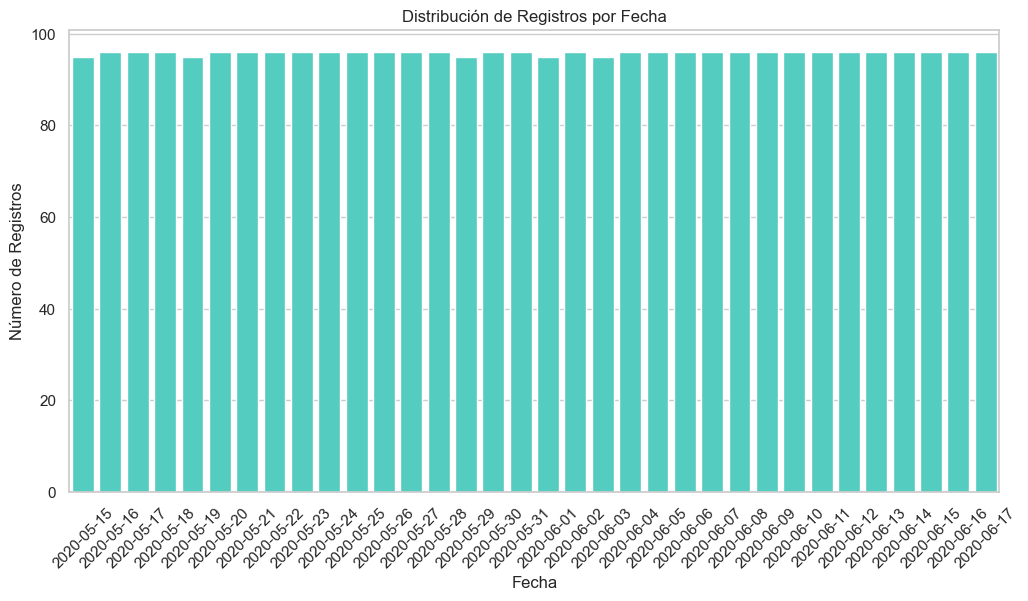

In [44]:
#Grafico de barras de registros totales diario (groupby por fecha_hora) en p2s con etiquetas de tiempo en eje x en todas las fechas disponibles en el dataset, con rotacion de 45 grados para las etiquetas del eje x y titulo "Distribución de Registros por Fecha"
plt.figure(figsize=(12, 6))
p2s['fecha'] = p2s['fecha_hora'].dt.date
daily_counts = p2s.groupby('fecha').size()
sns.barplot(x=daily_counts.index, y=daily_counts.values, color='turquoise')
plt.xticks(rotation=45)
plt.title("Distribución de Registros por Fecha")
plt.xlabel("Fecha")
plt.ylabel("Número de Registros")
plt.show()

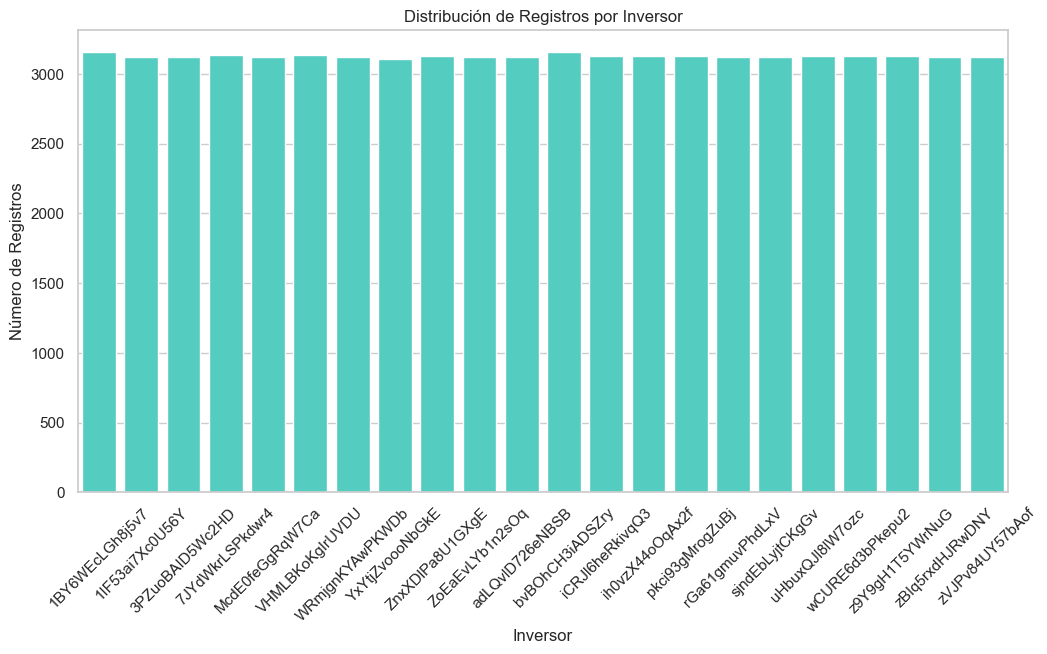

In [ ]:
#Grafico de barras de registros totales diario (groupby por id_inversor) en p1g
plt.figure(figsize=(12, 6))
inverter_counts = p1g.groupby('id_inversor').size()
sns.barplot(x=inverter_counts.index, y=inverter_counts.values, color='turquoise')
plt.xticks(rotation=45)
plt.title("Distribución de Registros por Inversor")
plt.xlabel("Inversor")
plt.ylabel("Número de Registros")
plt.show()

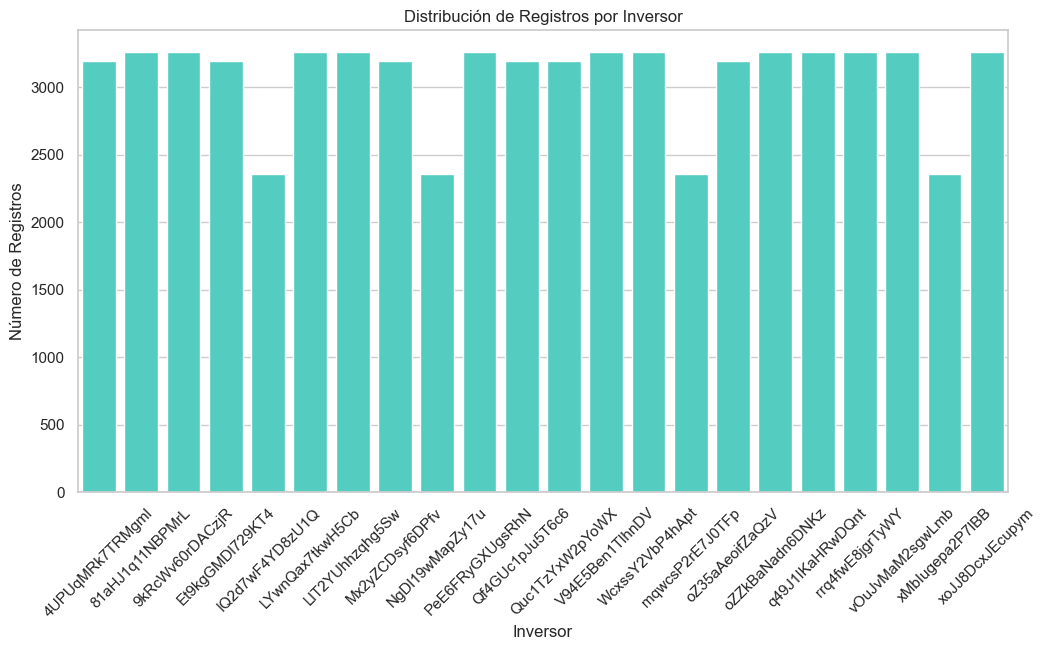

In [48]:
#Grafico de barras de registros totales diario (groupby por id_inversor) en p2g
plt.figure(figsize=(12, 6))
inverter_counts = p2g.groupby('id_inversor').size()
sns.barplot(x=inverter_counts.index, y=inverter_counts.values, color='turquoise')
plt.xticks(rotation=45)
plt.title("Distribución de Registros por Inversor")
plt.xlabel("Inversor")
plt.ylabel("Número de Registros")
plt.show()

### Insights 1, 2 y 3
1. El valor de los registros de DC en la planta 1 está a una escala 10 veces superior de lo que deberia, comparando con el resto de datos de la planta 2. Es muy probale que los errores sean de medicion y simplemente sea un problema de unidades al recoger los datos.
2. Tenemos irregularidades en los intervalkos de las series temporales tanto para los datasets de generacion como de sensores: Faltan registros de intervalos de 15 minutos.
3. Algunos inverters de la planta 2 muestran ausencia notable de registros (en concreto 4 de ellos). Continuar profundizando en este análisis en la fase de EDA.

In [49]:
#crear datasets combinados de generacion y sensores por separado
gener = pd.concat([p1g, p2g], axis='index')
sensor = pd.concat([p1s, p2s], axis='index')

sensor.head()

,fecha_hora,id_planta,id_sensor_meteorologico,temperatura_ambiente_c,temperatura_modulo_c,irradiacion_wh_m2,fecha
0,2020-05-15 00:00:00,p1,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,2020-05-15
1,2020-05-15 00:15:00,p1,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0,2020-05-15
2,2020-05-15 00:30:00,p1,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0,2020-05-15
3,2020-05-15 00:45:00,p1,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0,2020-05-15
4,2020-05-15 01:00:00,p1,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0,2020-05-15


In [51]:
#tabla combinada final decombinar gener con sensor
df = pd.merge(gener, sensor, on=['fecha_hora', 'id_planta'], how='left')
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 136476 entries, 0 to 136475
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   fecha_hora               136476 non-null  datetime64[us]
 1   id_planta                136476 non-null  str           
 2   id_inversor              136476 non-null  str           
 3   potencia_dc_kw           136476 non-null  float64       
 4   potencia_ac_kw           136476 non-null  float64       
 5   energia_diaria_kwh       136476 non-null  float64       
 6   energia_total_kwh        136476 non-null  float64       
 7   fecha_x                  136476 non-null  object        
 8   id_sensor_meteorologico  136472 non-null  str           
 9   temperatura_ambiente_c   136472 non-null  float64       
 10  temperatura_modulo_c     136472 non-null  float64       
 11  irradiacion_wh_m2        136472 non-null  float64       
 12  fecha_y                  13

In [53]:
#eliminamos nulos debido a que son muy muy pocos y no afecta al analisis
df = df.dropna()

In [55]:
#creamos objeto pickle (solo usable dentor de python, formato mas optimizado)
df.to_pickle('../datos/intermedios/tablon_analitico.pkl')